# Практика: DBSCAN — плотностная кластеризация

## Что вы сделаете
В этом ноутбуке вы:

1. исследуете нелинейные 2D-датасеты и убедитесь в ограничениях K-Means;
2. построите **k-distance plot** и выберете оптимальный параметр `eps`;
3. применените **DBSCAN** и проанализируете результаты;
4. сравните DBSCAN с K-Means на нелинейных данных;
5. исследуете влияние гиперпараметров `eps` и `min_samples`;
6. применените DBSCAN к реальному датасету **Wine** и проанализируете шумовые точки;
7. сравните силуэт DBSCAN и K-Means, сделаете выводы.

## Важно
- Заполняйте все ячейки с пометкой `# YOUR CODE HERE`.
- Не удаляйте проверки: они подскажут, правильно ли вы идёте.
- Вопросы для размышления помогут вам глубже понять алгоритм.

## Датасеты
- **`make_moons`** и **`make_circles`** из `sklearn.datasets`: 2D-данные с нелинейными кластерами.
- **Wine** (`load_wine`): реальный многомерный датасет (13 признаков, 3 класса).

## Что сдавать
1. Заполненный ноутбук со всеми графиками.
2. Краткие выводы в конце каждого раздела.
3. Итоговый вывод: когда DBSCAN лучше K-Means и когда нет.

## Краткая теория

### Типы точек в DBSCAN

DBSCAN задаётся двумя параметрами: радиусом окрестности `eps` (ε) и минимальным числом точек `min_samples`.

- **Корневая точка** (core): в её ε-окрестности ≥ `min_samples` точек.
- **Граничная точка** (border): в её ε-окрестности < `min_samples`, но она достижима из корневой.
- **Шумовая точка** (noise): не является ни корневой, ни граничной → метка **-1**.

### Как работает алгоритм

1. Для каждой непосещённой точки найти её ε-окрестность.
2. Если точек ≥ `min_samples` — начать новый кластер.
3. Рекурсивно расширить кластер через цепочки плотно достижимых точек.
4. Оставшиеся точки → шум (метка -1).

### Как выбрать eps: k-distance plot

Для каждой точки вычисляют расстояние до её k-го ближайшего соседа (k = `min_samples`). Отсортированный по убыванию график этих расстояний называется **k-distance plot**. Резкий перегиб («локоть») указывает на оптимальное значение `eps`.

---
## Шаг 1. Импорты и настройки

In [80]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.datasets import make_moons, make_circles, load_wine
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Импорты выполнены успешно!")

Импорты выполнены успешно!


---
## Шаг 2. Исследование нелинейных датасетов

Сгенерируем два датасета, с которыми K-Means заведомо не справится.

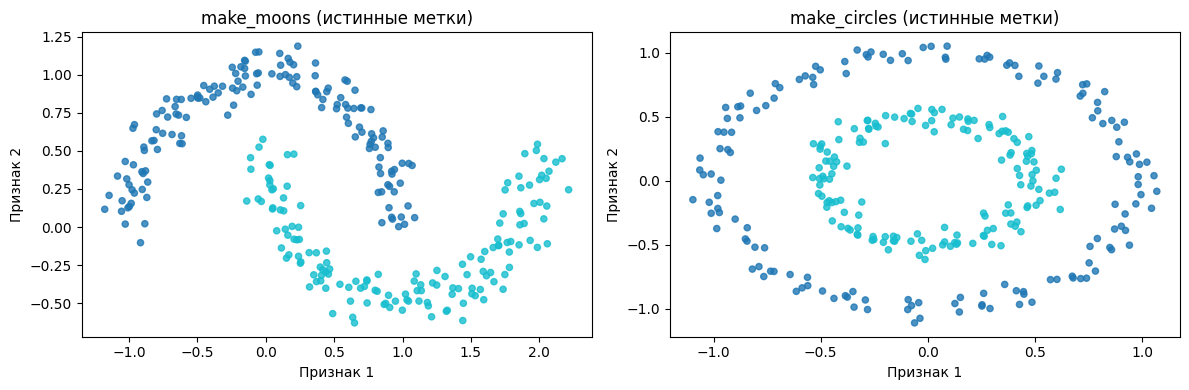

In [81]:
# Генерация датасетов
X_moons, y_moons = make_moons(n_samples=300, noise=0.08, random_state=RANDOM_STATE)
X_circles, y_circles = make_circles(n_samples=300, noise=0.05,
                                     factor=0.5, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1],
                c=y_moons, cmap='tab10', s=20, alpha=0.8)
axes[0].set_title("make_moons (истинные метки)")
axes[0].set_xlabel("Признак 1")
axes[0].set_ylabel("Признак 2")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                c=y_circles, cmap='tab10', s=20, alpha=0.8)
axes[1].set_title("make_circles (истинные метки)")
axes[1].set_xlabel("Признак 1")
axes[1].set_ylabel("Признак 2")

plt.tight_layout()
plt.show()

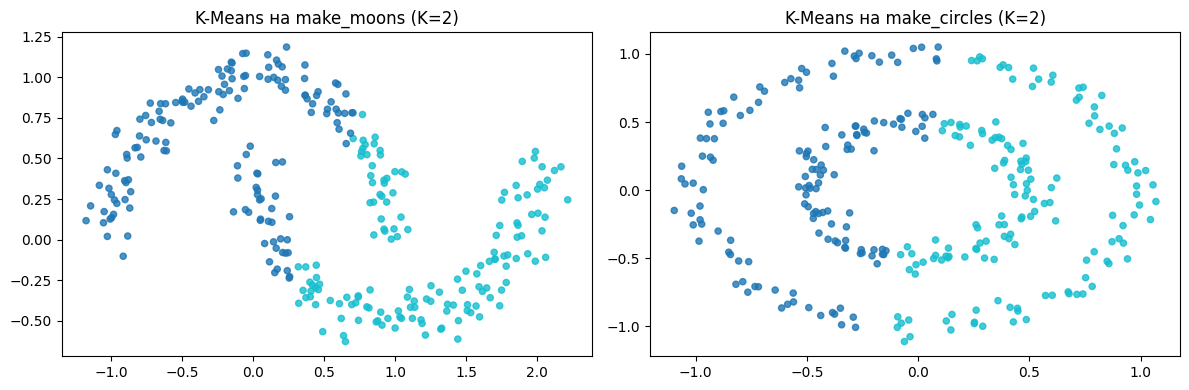

In [82]:
# Применим K-Means к этим датасетам
# YOUR CODE HERE
# 1. Создайте KMeans с n_clusters=2, random_state=RANDOM_STATE
# 2. Обучите на X_moons и X_circles
# 3. Получите метки кластеров
kmeans_moons = KMeans(n_clusters=2, random_state=RANDOM_STATE)  # замените None
labels_km_moons = kmeans_moons.fit_predict(X_moons, y_moons)

kmeans_circles = KMeans(n_clusters=2, random_state=RANDOM_STATE)
labels_km_circles = kmeans_circles.fit_predict(X_circles, y_circles)

# Визуализация результатов K-Means
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1],
                c=labels_km_moons, cmap='tab10', s=20, alpha=0.8)
axes[0].set_title("K-Means на make_moons (K=2)")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                c=labels_km_circles, cmap='tab10', s=20, alpha=0.8)
axes[1].set_title("K-Means на make_circles (K=2)")

plt.tight_layout()
plt.show()

**❓ Вопрос для размышления:** Почему K-Means не может правильно разделить «луны» и «кольца»? Связано ли это с формой функционала ошибки?

Да, это связано напрямую с функционалом ошибки - она минимизирует сумму квадратов расстояний от центроида кластера, что под собой подразумевает стремление K-means сходится к округлой форме

---
## Шаг 3. k-Distance Plot и выбор eps

Построим k-distance plot для датасета `make_moons`. Используем k = 5 (= `min_samples`).

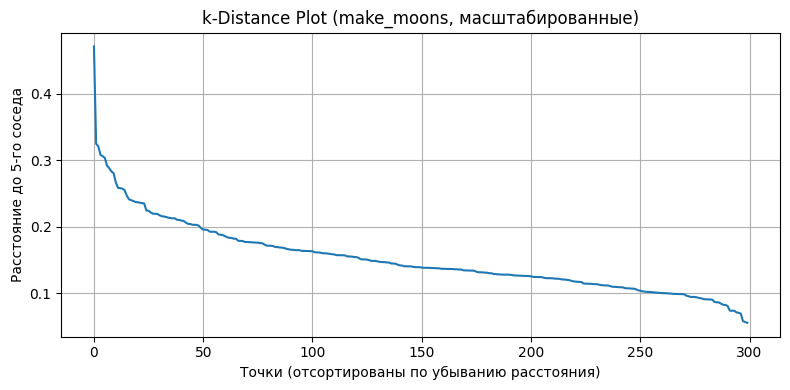

Найдите 'локоть' на графике и запишите подходящее значение eps:


In [83]:
# Масштабируем данные
scaler_moons = StandardScaler()
X_moons_scaled = scaler_moons.fit_transform(X_moons)

k = 5

# YOUR CODE HERE
# 1. Создайте NearestNeighbors(n_neighbors=k) и обучите на X_moons_scaled
# 2. Вызовите .kneighbors() для получения матрицы расстояний
# 3. Возьмите расстояние до k-го соседа (последний столбец distances)
# 4. Отсортируйте по убыванию

KNN = NearestNeighbors(n_neighbors=k)
KNN.fit(X_moons_scaled)

distances, _ = KNN.kneighbors(X_moons_scaled)

k_distances_moons =distances[:,-1] # замените
k_distances_moons = sorted(k_distances_moons, reverse=True)

plt.figure(figsize=(8, 4))
plt.plot(k_distances_moons)
plt.xlabel("Точки (отсортированы по убыванию расстояния)")
plt.ylabel(f"Расстояние до {k}-го соседа")
plt.title("k-Distance Plot (make_moons, масштабированные)")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Найдите 'локоть' на графике и запишите подходящее значение eps:")

**❓ Вопрос для размышления:** Где находится «локоть»? Как он указывает на границу между точками кластеров и шумом? 

Локоть находится в точке резкого замедления убывания функции, в данном случае он примерно равен eps=0.3


---
## Шаг 4. DBSCAN на нелинейных датасетах

Применим DBSCAN к `make_moons` и `make_circles`. Обратите внимание на масштабирование.

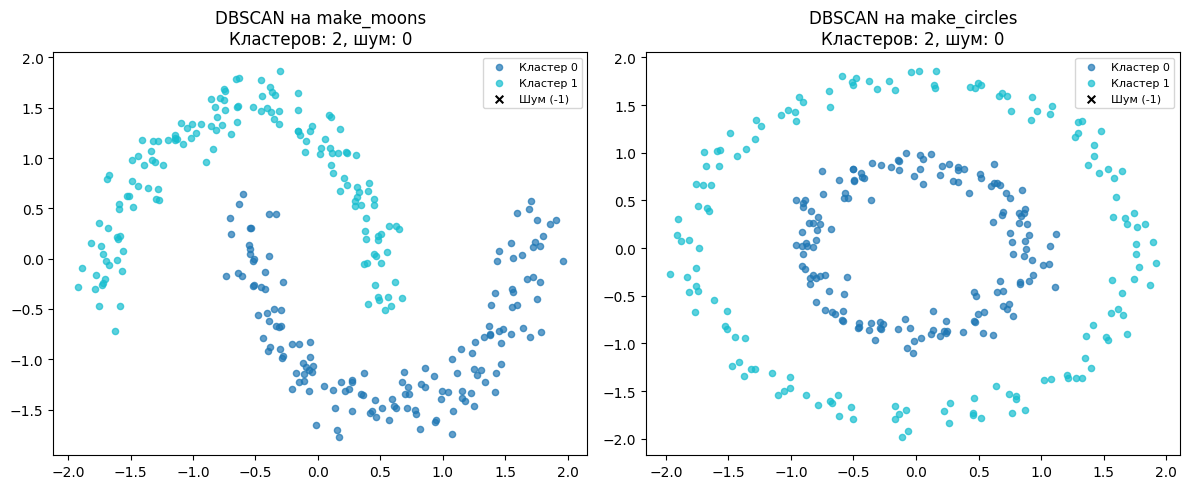

In [84]:
# Масштабируем make_circles
scaler_circles = StandardScaler()
X_circles_scaled = scaler_circles.fit_transform(X_circles)
eps = 0.31
# YOUR CODE HERE
# 1. Создайте DBSCAN с подобранным eps (из k-distance plot) и min_samples=5
# 2. Примените fit_predict к X_moons_scaled и X_circles_scaled
# 3. Подберите параметры так, чтобы алгоритм нашёл 2 кластера

db_moons = DBSCAN(eps=eps, min_samples=5)   # замените
labels_db_moons = db_moons.fit_predict(X_moons_scaled, y_moons)

db_circles = DBSCAN(eps=eps, min_samples=5)
labels_db_circles = db_circles.fit_predict(X_circles_scaled, y_circles)

# Вспомогательная функция для визуализации
def plot_dbscan_results(X, labels, title, ax):
    """Визуализирует результаты DBSCAN.
    Корневые точки — крупные, граничные — обычные, шум — крестики."""
    noise_mask = labels == -1
    colors = cm.tab10(np.linspace(0, 1, max(labels)+1)) if max(labels) >= 0 else []
    
    for i in range(max(labels)+1):
        mask = labels == i
        ax.scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.7,
                   color=colors[i], label=f'Кластер {i}')
    
    ax.scatter(X[noise_mask, 0], X[noise_mask, 1],
               s=30, c='black', marker='x', label='Шум (-1)')
    
    n_cl = max(labels) + 1 if max(labels) >= 0 else 0
    n_noise = noise_mask.sum()
    ax.set_title(f"{title}\nКластеров: {n_cl}, шум: {n_noise}")
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_dbscan_results(X_moons_scaled, labels_db_moons, "DBSCAN на make_moons", axes[0])
plot_dbscan_results(X_circles_scaled, labels_db_circles, "DBSCAN на make_circles", axes[1])
plt.tight_layout()
plt.show()

---
## Шаг 5. Сравнение DBSCAN и K-Means на нелинейных данных

In [85]:
# Сравнение силуэта DBSCAN vs K-Means для make_moons

# YOUR CODE HERE
# 1. Обучите KMeans(n_clusters=2) на X_moons_scaled
# 2. Вычислите silhouette_score для K-Means
# 3. Вычислите silhouette_score для DBSCAN (только для некластерных точек!)
#    Подсказка: исключите точки с labels == -1
Kmeans_scaled = KMeans(n_clusters=2)
labels_scaled_km = Kmeans_scaled.fit_predict(X_moons_scaled, y_moons)
score_kmeans = silhouette_score(X=X_moons_scaled, labels=labels_scaled_km)  # замените
mask_db = labels_db_moons != -1
score_dbscan = silhouette_score(X_moons_scaled[mask_db], labels_db_moons[mask_db])

print("=== Коэффициент силуэта на make_moons ===")
print(f"K-Means (K=2): {score_kmeans:.3f}" if score_kmeans is not None else "K-Means: не вычислен")
print(f"DBSCAN:        {score_dbscan:.3f}" if score_dbscan is not None else "DBSCAN: не вычислен")

=== Коэффициент силуэта на make_moons ===
K-Means (K=2): 0.494
DBSCAN:        0.380


**❓ Вопрос для размышления:** Какой алгоритм получил лучший силуэт? Соответствует ли это визуальному впечатлению? Можно ли всегда доверять силуэту как абсолютной мере качества?

Лучший силуэт получил K-means, хотя визуально видно, что DBSCAN намного лучше и правильнее разделил классы. Соответственно, не стоит всегда доверять силуэту как абсолютной мере качества, дабы избежать таких неверных интрепретаций

---
## Шаг 6. Исследование влияния гиперпараметров

Посмотрим, как меняется результат DBSCAN при разных значениях `eps` и `min_samples`.

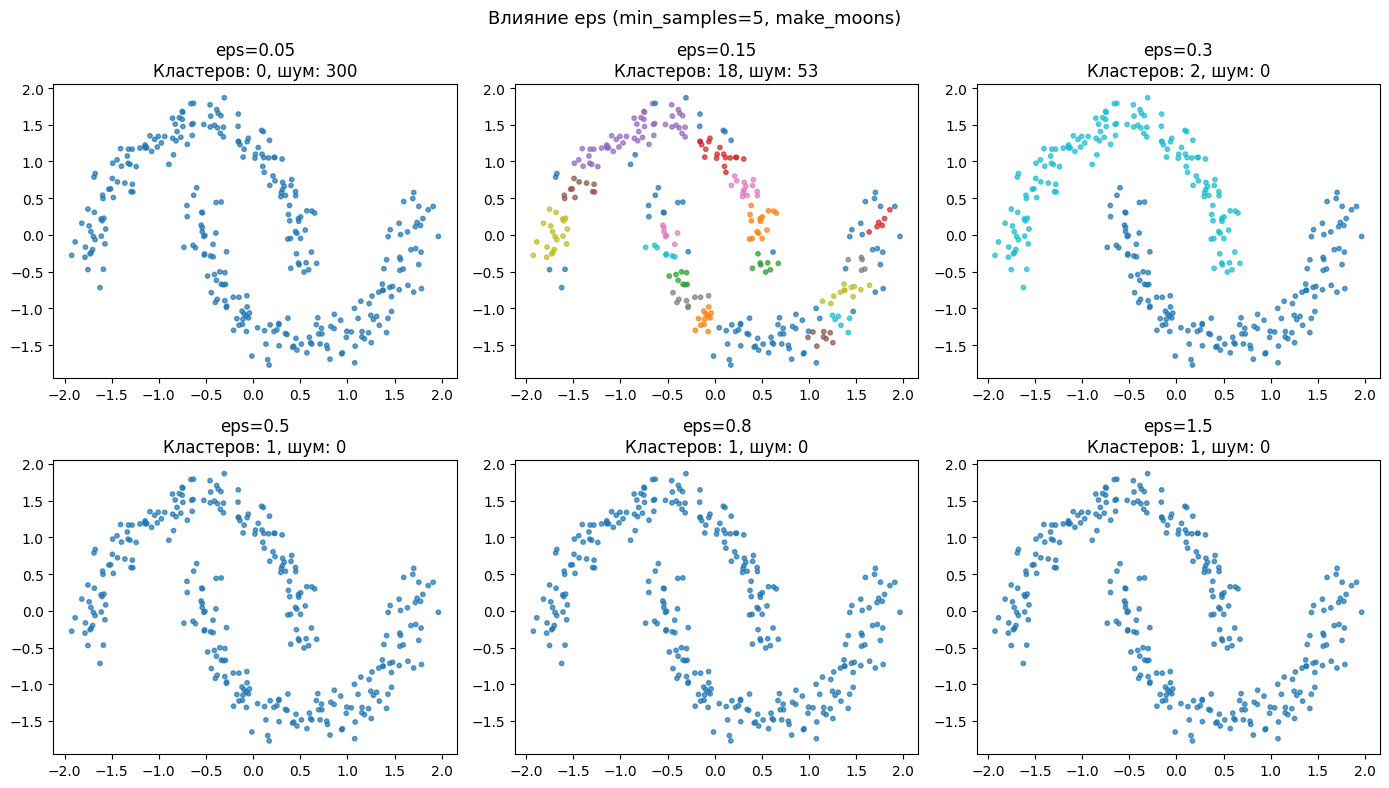

In [86]:
# Сетка eps при фиксированном min_samples=5
eps_values = [0.05, 0.15, 0.3, 0.5, 0.8, 1.5]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, eps_val in enumerate(eps_values):
    # YOUR CODE HERE
    # 1. Запустите DBSCAN(eps=eps_val, min_samples=5) на X_moons_scaled
    # 2. Получите метки
    # 3. Посчитайте число кластеров и шумовых точек
    # 4. Отобразите scatter plot с цветами по меткам
    #    Шумовые точки (label == -1) рисуйте чёрными крестиками
    estimator =DBSCAN(eps=eps_val, min_samples=5)
    

    labels_i = estimator.fit_predict(X_moons_scaled, y_moons)  # замените
    
    if labels_i is not None:
        n_cl = len(set(labels_i)) - (1 if -1 in labels_i else 0)
        n_noise = (labels_i == -1).sum()
        axes[i].scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1],
                        c=labels_i, cmap='tab10', s=10, alpha=0.7)
        axes[i].set_title(f"eps={eps_val}\nКластеров: {n_cl}, шум: {n_noise}")
    else:
        axes[i].set_title(f"eps={eps_val} (не вычислено)")

plt.suptitle("Влияние eps (min_samples=5, make_moons)", fontsize=13)
plt.tight_layout()
plt.show()

**❓ Вопрос для размышления:** При каком `eps` алгоритм нашёл два правильных кластера? Что происходит при слишком малом и слишком большом значении? 

Алгоритм нашёл два правильных кластера при eps = 0.3. Меньше eps - слишком много кластеров (вплоть до того, что все точки - шум), больше - 1 общий кластер

---
## Шаг 7. DBSCAN на реальном датасете Wine

Теперь перейдём к реальным данным. Датасет Wine: 178 образцов вина из трёх сортов винограда, 13 химических признаков.

In [87]:
# Загрузка датасета Wine
wine = load_wine()
X_wine = wine.data
y_wine = wine.target  # истинные метки (не используем при кластеризации!)
feature_names = wine.feature_names

print(f"Форма данных: {X_wine.shape}")
print(f"Признаки: {feature_names}")
print(f"\nСтатистика признаков:")
df_wine = pd.DataFrame(X_wine, columns=feature_names)
print(df_wine.describe().round(2))

Форма данных: (178, 13)
Признаки: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Статистика признаков:
       alcohol  malic_acid     ash  alcalinity_of_ash  magnesium  \
count   178.00      178.00  178.00             178.00     178.00   
mean     13.00        2.34    2.37              19.49      99.74   
std       0.81        1.12    0.27               3.34      14.28   
min      11.03        0.74    1.36              10.60      70.00   
25%      12.36        1.60    2.21              17.20      88.00   
50%      13.05        1.87    2.36              19.50      98.00   
75%      13.68        3.08    2.56              21.50     107.00   
max      14.83        5.80    3.23              30.00     162.00   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count         178.00      178.00             

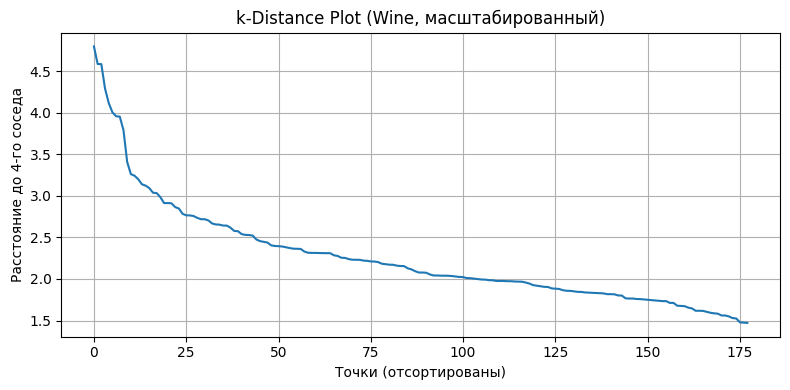

In [88]:
# YOUR CODE HERE
# 1. Масштабируйте X_wine с помощью StandardScaler
# 2. Постройте k-distance plot (k=4)
# 3. Визуально определите «локоть» и запишите подходящее eps
wine_scaler = StandardScaler()
X_wine_scaled = wine_scaler.fit_transform(X_wine)  # замените

k_wine = 4
KNN_wine = NearestNeighbors(n_neighbors=k_wine)
KNN_wine.fit(X_wine_scaled)
wine_distances, _ = KNN_wine.kneighbors(X_wine_scaled)
k_dist_wine = wine_distances[:, -1]
k_dist_wine = sorted(k_dist_wine, reverse=True)

plt.figure(figsize=(8, 4))
if k_dist_wine is not None:
    plt.plot(k_dist_wine)
plt.xlabel("Точки (отсортированы)")
plt.ylabel(f"Расстояние до {k_wine}-го соседа")
plt.title("k-Distance Plot (Wine, масштабированный)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [89]:
# YOUR CODE HERE
# 1. Запустите DBSCAN на X_wine_scaled с выбранным eps и min_samples=4
# 2. Выведите: число кластеров, число шумовых точек, долю шума
# 3. Если кластеров > 1, вычислите силуэт (исключив шум)

eps_wine = 2.1   # ИЗМЕНИТЕ на основе k-distance plot

wine_db = DBSCAN(eps=eps_wine, min_samples=4)
labels_wine = wine_db.fit_predict(X_wine_scaled)  # замените

print("=== Результаты DBSCAN на Wine ===")

n_clusters = len(set(labels_wine)) - (1 if -1 in labels_wine else 0)
n_noise = (labels_wine == -1).sum()
print(f"Кластеров: {n_clusters}")
print(f"Шумовых точек: {n_noise} ({n_noise / len(labels_wine) * 100:.1f}%)")

if n_clusters > 1:
    mask = labels_wine != -1
    score = silhouette_score(X_wine_scaled[mask], labels_wine[mask])
    print(f"Силуэт (без шума): {score:.3f}")

=== Результаты DBSCAN на Wine ===
Кластеров: 3
Шумовых точек: 57 (32.0%)
Силуэт (без шума): 0.211


---
## Шаг 8. Анализ шумовых точек

Шумовые точки — это объекты, которые DBSCAN не смог отнести ни к одному кластеру. В задаче кластеризации они могут нести важную информацию.

In [92]:
# YOUR CODE HERE
# 1. Выберите строки X_wine, соответствующие шумовым точкам (labels_wine == -1)
# 2. Создайте DataFrame с признаками шумовых точек
# 3. Сравните среднее значение признаков шумовых точек
#    со средним по всей выборке (df_wine.mean())
# 4. Какие признаки у шумовых точек сильно отличаются от среднего?

noise_mask_wine = labels_wine == -1   # маска для шумовых точек
X_wine_noise = X_wine[noise_mask_wine]      # признаки шумовых точек

df_noise = pd.DataFrame(X_wine_noise, columns=feature_names)
df_all = pd.DataFrame(X_wine, columns=feature_names)

print("=== Средние значения признаков ===")
comparison = pd.DataFrame({
    'Вся выборка': df_all.mean(),
    'Шумовые точки': df_noise.mean(),
    'Разница (%)': ((df_noise.mean() - df_all.mean()) / df_all.mean() * 100).round(1)
})
print(comparison.round(2))

=== Средние значения признаков ===
                              Вся выборка  Шумовые точки  Разница (%)
alcohol                             13.00          12.74         -2.0
malic_acid                           2.34           2.55          9.0
ash                                  2.37           2.35         -0.6
alcalinity_of_ash                   19.49          20.09          3.0
magnesium                           99.74         101.11          1.4
total_phenols                        2.30           2.34          2.0
flavanoids                           2.03           2.02         -0.6
nonflavanoid_phenols                 0.36           0.37          2.9
proanthocyanins                      1.59           1.71          7.7
color_intensity                      5.06           4.45        -12.1
hue                                  0.96           0.97          1.8
od280/od315_of_diluted_wines         2.61           2.54         -2.7
proline                            746.89         645.3

**❓ Вопрос для размышления:** Чем отличаются шумовые точки от остальных? Являются ли они «плохими» данными или это реальные аномалии?

Шумовые точки отличаются нетипичными значениями признаков (в сравнении с остальными точками) и являются реальными происходящими в жизни аномалиями (не плохими данными)

---
## Шаг 9. Итоговое сравнение: DBSCAN vs K-Means на Wine

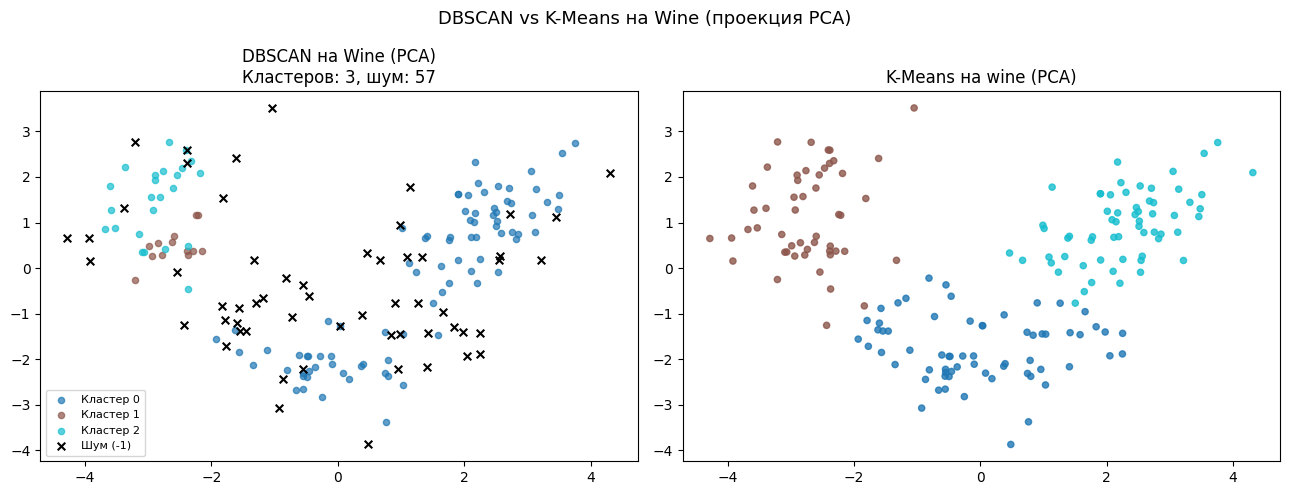

In [ ]:
# YOUR CODE HERE
# 1. Обучите KMeans с числом кластеров = числу кластеров DBSCAN
#    (или с n_clusters=3, так как истинных классов 3)
# 2. Вычислите силуэт для K-Means
# 3. Сравните силуэт DBSCAN и K-Means
# 4. Визуализируйте результаты обоих методов в 2D (первые два признака
#    после масштабирования или используйте PCA до 2 компонент)

# Подсказка для PCA:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_wine_2d = pca.fit_transform(X_wine_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

final_kmeans = KMeans(n_clusters=3,random_state=RANDOM_STATE)
km_preds = final_kmeans.fit_predict(X_wine_scaled)

plt.suptitle("DBSCAN vs K-Means на Wine (проекция PCA)", fontsize=13)

plot_dbscan_results(X_wine_2d, labels_wine, "DBSCAN на Wine (PCA)", axes[0])

axes[1].scatter(X_wine_2d[:, 0], X_wine_2d[:, 1],
                c=km_preds, cmap='tab10', s=20, alpha=0.8)
axes[1].set_title("K-Means на wine (PCA)")
plt.tight_layout()
plt.show()
score_km_wine = silhouette_score(X_wine_scaled, km_preds)
mask_wine = labels_wine != -1
score_db_wine = silhouette_score(X_wine_scaled[mask_wine], labels_wine[mask_wine])
print(f"Силуэт K-Means: {score_km_wine:.3f}")
print(f"Силуэт DBSCAN (без шума): {score_db_wine:.3f}")

---
## Шаг 10. Итоговые выводы

Ответьте на следующие вопросы в ячейке ниже (текст Markdown):

**1. Когда DBSCAN выигрывает у K-Means?**

> На классах,имеющих не круговидную форму (месяцы, вложенные фигуры), когда количество кластеров заранее неизвестно и когда в данных присутствуют выбросы, которые следует пометить и принудительно не включать в какой-либо кластер

**2. Когда K-Means предпочтительнее?**

> Когда кластеры имеют приблизительно округлую форму, схожи по размеру/плотности, и когда K изместен заранее

**3. Почему масштабирование обязательно для DBSCAN?**

> DBSCAN основан на расстоянях (eps), и если диапазон значений одного признака составляет от 0 до 1000, а другого - от 0 до 1, то в определении расстояний будет доминировать более крупный признак, а маленький будет проигнорирован

**4. Как интерпретировать шумовые точки в датасете Wine?**

> Шумовые точки — вина с необычным химическим профилем(среднее признаков удалено от среднего по всему датасету), которые находятся между кластерами, не относятся однозначно к одному из них, являются нетипичными

**5. Можно ли корректно сравнивать силуэт DBSCAN и K-Means напрямую? Почему?**

> Нет, как минимум потому, что в DBSCANе он считается без шумовых точек, а в К-means - включает все точки. Также, силуэт больше симпатизирует округлым формам (к примеру, в секции 4 силуэт K-means получился на 0.2 выше, хотя разделение было правильным у DBSCAN и неправильным (но округлым) у K-means)